In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

In [ ]:
# Study hours
study_hours = tf.constant([0.1, 0.3, 0.5, 0.7, 0.9], dtype=tf.float32)

# Output labels: 0 = Fail, 1 = Pass
result = tf.constant([0, 0, 0, 1, 1], dtype=tf.float32)

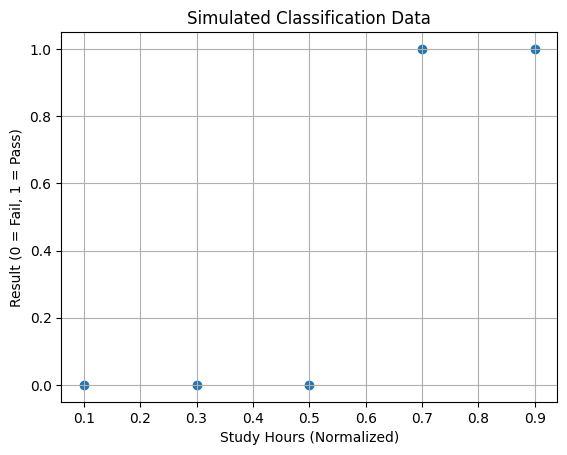

In [ ]:
# Plot data
plt.scatter(study_hours, result)
plt.xlabel("Study Hours (Normalized)")
plt.ylabel("Result (0 = Fail, 1 = Pass)")
plt.title("Simulated Classification Data")
plt.grid(True)
plt.show()

In [ ]:
w_eager = tf.Variable(0.0)
b_eager = tf.Variable(0.0)

learning_rate = 0.5
epochs = 100

for i in range(epochs):
    with tf.GradientTape() as tape:
        logits = w_eager * study_hours + b_eager
        pred = tf.sigmoid(logits)
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(result, pred)
        )

    grads = tape.gradient(loss, [w_eager, b_eager])
    w_eager.assign_sub(learning_rate * grads[0])
    b_eager.assign_sub(learning_rate * grads[1])

    if i % 20 == 0:
        print(f"[Eager] Step {i} : Loss = {loss.numpy():.4f}")

[Eager] Step 0 : Loss = 0.6931
[Eager] Step 20 : Loss = 0.5862
[Eager] Step 40 : Loss = 0.5108
[Eager] Step 60 : Loss = 0.4541
[Eager] Step 80 : Loss = 0.4104


In [ ]:
w_graph = tf.Variable(0.0)
b_graph = tf.Variable(0.0)

@tf.function
def train_step(x, y, w, b):
    with tf.GradientTape() as tape:
        logits = w * x + b
        pred = tf.sigmoid(logits)
        loss = tf.reduce_mean(
            tf.keras.losses.binary_crossentropy(y, pred)
        )

    grads = tape.gradient(loss, [w, b])
    w.assign_sub(learning_rate * grads[0])
    b.assign_sub(learning_rate * grads[1])
    return loss


In [ ]:
for i in range(epochs):
    loss_graph = train_step(study_hours, result, w_graph, b_graph)
    if i % 20 == 0:
        print(f"[Graph] Step {i} : Loss = {loss_graph.numpy():.4f}")

[Graph] Step 0 : Loss = 0.6931
[Graph] Step 20 : Loss = 0.5862
[Graph] Step 40 : Loss = 0.5108
[Graph] Step 60 : Loss = 0.4541
[Graph] Step 80 : Loss = 0.4104


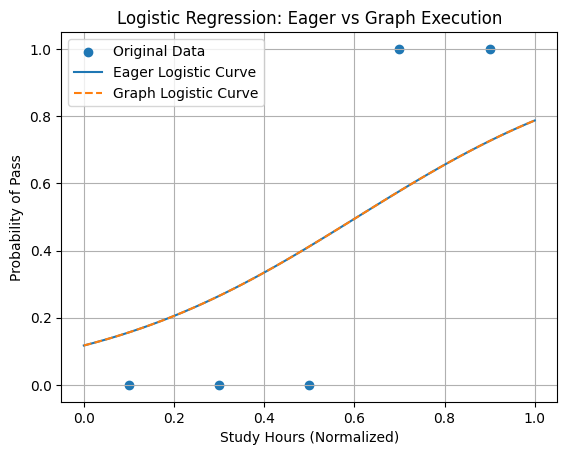

In [ ]:
x_vals = tf.linspace(0.0, 1.0, 100)

plt.scatter(study_hours, result, label="Original Data")

plt.plot(
    x_vals,
    tf.sigmoid(w_eager * x_vals + b_eager),
    label="Eager Logistic Curve",
)

plt.plot(
    x_vals,
    tf.sigmoid(w_graph * x_vals + b_graph),
    linestyle="--",
    label="Graph Logistic Curve",
)

plt.xlabel("Study Hours (Normalized)")
plt.ylabel("Probability of Pass")
plt.title("Logistic Regression: Eager vs Graph Execution")
plt.grid(True)
plt.legend()
plt.show()